# Analisis de sensibilidad entre precios y volumenes

## Estracción de información

In [22]:
#pip install openpyxl
#pip install pandas pyxlsb

In [1]:
import pandas as pd
import numpy as np

# Ruta del archivo
ruta = r"C:\Users\preci\TRANSPORTES C MORALES C SA de CV\Tesorería y Finanzas Treher - Finanzas Grupo Treher\01.Diarios\BD_VENTAS.xlsx"

# Leer la hoja DB
BD = pd.read_excel(
    ruta,
    sheet_name="BD",
    engine="openpyxl",
    header=0
)

# Convertir fecha a datetime
BD["Fecha"] = pd.to_datetime(BD["Fecha"])

# Ordenar por estación y fecha
BD = BD.sort_values(["Estación", "Fecha"]).reset_index(drop=True)

# Columnas a interpolar
cols_interpolar = [
    "Diésel (Lts)",
    "Premium (Lts)",
    "Regular (Lts)",
    "Precio D",
    "Precio P",
    "Precio R"
]

# FUNCIÓN CORREGIDA: solo promedia datos reales previos
def fill_zeros_with_rolling_mean_excel(s, window=15, min_obs=1):
    s = s.copy()

    # identificar ceros originales
    mask_zero = s == 0

    # trabajar solo con datos reales
    s_real = s.replace(0, np.nan)

    # promedio de observaciones reales PREVIAS
    rolling_mean = (
        s_real
        .shift(1)
        .rolling(window=window, min_periods=min_obs)
        .mean()
    )

    # rellenar solo los ceros originales
    s.loc[mask_zero] = rolling_mean[mask_zero]

    return s

# Aplicar por estación y columna
BD[cols_interpolar] = (
    BD
    .groupby("Estación")[cols_interpolar]
    .apply(lambda df: df.apply(fill_zeros_with_rolling_mean_excel))
    .reset_index(level=0, drop=True)
)

# Recalculo de importes
BD["Importe Diésel"]   = BD["Diésel (Lts)"] * BD["Precio D"]
BD["Importe Premium"] = BD["Premium (Lts)"] * BD["Precio P"]
BD["Importe Regular"] = BD["Regular (Lts)"] * BD["Precio R"]

# Recalculo de totales
BD["Total LTS"] = (
    BD["Diésel (Lts)"] +
    BD["Premium (Lts)"] +
    BD["Regular (Lts)"]
)

BD["Total venta ($)"] = (
    BD["Importe Diésel"] +
    BD["Importe Premium"] +
    BD["Importe Regular"]
)

# Variables de tiempo
BD["Trimestre"] = ((BD["Mes"] - 1) // 3 + 1).astype(int)
BD["Dia_semana"] = BD["Fecha"].dt.dayofweek

# En lugar de print(len()), usa esto:
print(f"Total de filas en BD: {len(BD)}")
print(f"Filas con datos nulos: {BD[cols_interpolar].isna().sum().sum()}")
print(f"Estaciones procesadas: {BD['Estación'].nunique()}")

# Corre una prueba para una sola estación y mira el tamaño de 'temp'
test_estacion = BD["Estación"].unique()[0]
df_test = BD[BD["Estación"] == test_estacion]
print(f"Registros para {test_estacion}: {len(df_test)}")
BD = BD.drop_duplicates(subset=["Estación","Fecha"], keep="first")


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\preci\\TRANSPORTES C MORALES C SA de CV\\Tesorería y Finanzas Treher - Finanzas Grupo Treher\\01.Diarios\\BD_VENTAS.xlsx'

In [2]:
import pandas as pd
import numpy as np

# Ruta del archivo
ruta = r"C:\Users\preci\TRANSPORTES C MORALES C SA de CV\Tesorería y Finanzas Treher - Finanzas Grupo Treher\01.Diarios\00.Analisis de ventas\BD_VENTAS.xlsx"

# Leer la hoja DB
BD = pd.read_excel(
    ruta,
    sheet_name="BD",
    engine="openpyxl",
    header=0
)

# Convertir fecha a datetime
BD["Fecha"] = pd.to_datetime(BD["Fecha"])

# Ordenar por estación y fecha
BD = BD.sort_values(["Estación", "Fecha"]).reset_index(drop=True)
BD[["Diésel (Lts)", "Premium (Lts)", "Regular (Lts)","Precio D","Precio P","Precio R"]] = (
    BD[["Diésel (Lts)", "Premium (Lts)", "Regular (Lts)","Precio D","Precio P","Precio R"]]
    .replace([0, "", " ", "#N/A", "#DIV/0!", "#VALUE!", "#REF!", "#NAME?"], np.nan)
)

BD.to_excel(
    "BD_Limpia.xlsx",
    index=False,
    engine="openpyxl"
)

## Analisis preliminares

### Funciones auxiliares

In [5]:
#pip install statsmodels                           lo anterior correr solo una vez, es una libreria necesaria para funcionar, pero una vez installada, ya no es necesaria volverla a correr

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
import pandas as pd


In [7]:
#GRAFICAS DE FECHAS VS LITROS, Y FECHAS VS PRECIOS ------------------------------------------------------

def lts_precio(BD, estacion):

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    # =========================
    # FILTRO Y PREPARACIÓN
    # =========================
    df = (
        BD[BD["Estación"] == estacion]
        .sort_values("Fecha")
        .copy()
    )

    if df.empty:
        raise ValueError(f"No hay datos para la estación {estacion}")

    # Ingresos
    df["Ingreso D"] = df["Diésel (Lts)"] * df["Precio D"]
    df["Ingreso P"] = df["Premium (Lts)"] * df["Precio P"]
    df["Ingreso R"] = df["Regular (Lts)"] * df["Precio R"]

    # =========================
    # DEFINICIÓN DE SERIES
    # =========================
    series = [
        ("Diésel (Lts)",  "Diésel – Litros",   "Litros",        "black",     "litros"),
        ("Precio D",      "Diésel – Precio",   "Precio ($/lt)", "black",     "precio"),
        ("Ingreso D",     "Diésel – Ingreso",  "Ingreso ($)",   "black",     "ingreso"),

        ("Premium (Lts)", "Premium – Litros",  "Litros",        "red",       "litros"),
        ("Precio P",      "Premium – Precio",  "Precio ($/lt)", "red",       "precio"),
        ("Ingreso P",     "Premium – Ingreso", "Ingreso ($)",   "red",       "ingreso"),

        ("Regular (Lts)", "Regular – Litros",  "Litros",        "steelblue", "litros"),
        ("Precio R",      "Regular – Precio",  "Precio ($/lt)", "steelblue", "precio"),
        ("Ingreso R",     "Regular – Ingreso", "Ingreso ($)",   "steelblue", "ingreso"),
    ]

    # =========================
    # FIGURA
    # =========================
    fig, axes = plt.subplots(
        nrows=9,
        ncols=1,
        figsize=(16, 30),
        sharex=False
    )

    locator = mdates.MonthLocator(interval=2)
    formatter = mdates.DateFormatter("%Y-%m")

    fecha_evento = pd.Timestamp("2026-03-21")  # opcional

    # =========================
    # LOOP DE GRAFICADO
    # =========================
    for ax, (col, titulo, ylabel, color, tipo) in zip(axes, series):
          
        ax.plot(
            df["Fecha"],
            df[col],
            color=color,
            linewidth=1.4,
            alpha=0.65
        )
        
        ax.axvline(
            x=fecha_evento,
            color="black",
            linestyle=":",
            linewidth=1.6,
            alpha=0.8
        )
    
        # ===== LITROS =====
        if tipo == "litros":

            ewma_mean = df[col].rolling(14).mean()

            ax.plot(
                df["Fecha"],
                ewma_mean,
                color=color,
                linewidth=2.4,
                linestyle="--"
            )

            ewma_var = (df[col] - ewma_mean).pow(2).ewm(
                span=14,
                adjust=False
            ).mean()

            ewma_std = np.sqrt(ewma_var)

            x_last = df["Fecha"].iloc[-1]
            mean_last = ewma_mean.iloc[-1]
            std_last  = ewma_std.iloc[-1]

            ax.annotate(
                f"μ={mean_last:,.0f}\nσ={std_last:,.0f}",
                xy=(x_last, mean_last),
                xytext=(10, 0),
                textcoords="offset points",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=color,
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    fc="white",
                    alpha=0.9
                )
            )

        # ===== PRECIOS =====
        elif tipo == "precio":

            precio_prom = df[col].mean()
            precio_last = df[col].iloc[-1]
            x_last = df["Fecha"].iloc[-1]

            ax.annotate(
                f"Prom. hist: ${precio_prom:,.2f}\n"
                f"Último: ${precio_last:,.2f}",
                xy=(x_last, precio_last),
                xytext=(10, 0),
                textcoords="offset points",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=color,
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    fc="white",
                    alpha=0.9
                )
            )

        # ===== INGRESOS =====
        elif tipo == "ingreso":

            ingreso_hist = df[col].mean()
            ingreso_7d   = df[col].tail(7).mean()

            x_last = df["Fecha"].iloc[-1]
            y_last = df[col].iloc[-1]

            ax.annotate(
                f"Prom. hist: ${ingreso_hist:,.0f}\n"
                f"Prom. 7 días: ${ingreso_7d:,.0f}",
                xy=(x_last, y_last),
                xytext=(10, 0),
                textcoords="offset points",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=color,
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    fc="white",
                    alpha=0.9
                )
            )

        # ===== FORMATO =====
        ax.set_title(titulo, fontsize=12)
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Fecha")

        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)

        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.3)

    fig.suptitle(
        f"Evolución de Litros, Precios e Ingresos – Estación {estacion}",
        fontsize=16
    )

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()



In [8]:
#####################3-------------------------- MODELO RLM + FOURIER -----------###########################################333

#------------LIBRERIAS NECESARIAS PARA EL FUNCIONAMIENTO DEL CÓDIGO
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import (
    acorr_breusch_godfrey,
    het_breuschpagan
)
from scipy.stats import jarque_bera

#############################################_-------------------------------------------GRÁFICAS OPCIONALES DE VISUALIZACIÓN#____________________##############################
def graficas_residuos(modelo, lags_acf=30, titulo_extra=""):
    import matplotlib.pyplot as plt
    from statsmodels.graphics.tsaplots import plot_acf
    import numpy as np
    import pandas as pd

    # Extraer residuos y fitted
    residuos = pd.Series(modelo.resid).reset_index(drop=True)
    fitted = pd.Series(modelo.fittedvalues).reset_index(drop=True)

    fig, axs = plt.subplots(2, 2, figsize=(10,6))
    fig.suptitle(f"Diagnóstico de Residuos {titulo_extra}", fontsize=14)

    # 1️⃣ Residuos vs tiempo
    axs[0, 0].plot(residuos)
    axs[0, 0].axhline(0, color="red", linestyle="--")
    axs[0, 0].set_title("Residuos en el tiempo")
    axs[0, 0].set_xlabel("Tiempo")
    axs[0, 0].set_ylabel("Residuo")

    # 2️⃣ Residuos vs fitted
    axs[0, 1].scatter(fitted, residuos, alpha=0.5)
    axs[0, 1].axhline(0, color="red", linestyle="--")
    axs[0, 1].set_title("Residuos vs valores ajustados")
    axs[0, 1].set_xlabel("ŷ (fitted)")
    axs[0, 1].set_ylabel("Residuo")

    # 3️⃣ Histograma de residuos
    axs[1, 0].hist(residuos, bins=30, density=True, alpha=0.7)
    axs[1, 0].set_title("Distribución de residuos")
    axs[1, 0].set_xlabel("Residuo")
    axs[1, 0].set_ylabel("Densidad")

    # 4️⃣ ACF de residuos
    plot_acf(residuos, lags=lags_acf, ax=axs[1, 1])
    axs[1, 1].set_title("ACF de residuos")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


#######_------------SEMÁFORO DE ADVERTENCIA DE CONFIABILIDAD
def semaforo(score):
    if score >= 80:
        return "🟢"
    elif score >= 60:
        return "🟡"
    elif score >= 40:
        return "🟠"
    else:
        return "🔴"
    
############--------------TEST PARA LA CONFIABILIDAD DE LA SERIE DE FOURIER
def tests_fourier(modelo, temp, fourier_cols):

    if len(fourier_cols) == 0:
        return {
            "p_fourier": 1.0,
            "pico_anual": False,
            "estable_K": False
        }

    hyp = " = ".join(f"{c} = 0" for c in fourier_cols)
    ftest = modelo.f_test(hyp)

    return {
        "p_fourier": float(ftest.pvalue),
        "pico_anual": True,     # placeholder
        "estable_K": True       # placeholder
    }
    

#########------------TEST PARA LA PRUEBA DE RESIDUOS
def tests_residuos(modelo):
    res = modelo.resid
    exog = modelo.model.exog

    dw = durbin_watson(res)
    _, bg_p, _, _ = acorr_breusch_godfrey(modelo, nlags=7)
    _, bp_p, _, _ = het_breuschpagan(res, exog)
    _, jb_p = jarque_bera(res)

    return {
        "DW": float(dw),
        "bg_p": float(bg_p),
        "bp_p": float(bp_p),
        "jb_p": float(jb_p)
    }

######------------TEST ESTRUCTURALES
def tests_estructura(modelo_ols, X, y, ventana=180):
    # 1. Significancia
    p_lambda = modelo_ols.pvalues.get("t_c", 1.0)
    lambda_hat = modelo_ols.params.get("t_c", 0.0)

    lambda_significativo = p_lambda < 0.05

    # 2. Estabilidad rolling
    lambdas = []
    for i in range(ventana, len(y)):
        y_sub = y.iloc[i-ventana:i]
        X_sub = X.iloc[i-ventana:i]
        try:
            m = sm.OLS(y_sub, X_sub).fit()
            lambdas.append(m.params.get("t_c", np.nan))
        except:
            continue

    lambdas = pd.Series(lambdas).dropna()

    if len(lambdas) > 10:
        coef_var = lambdas.std() / abs(lambdas.mean())
        lambda_estable = coef_var < 0.5
    else:
        lambda_estable = False

    # 3. Robustez HAC
    modelo_hac = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags":7}
    )

    lambda_hac = modelo_hac.params.get("t_c", 0.0)
    robusto_hac = np.sign(lambda_hat) == np.sign(lambda_hac)

    return {
        "lambda_significativo": lambda_significativo,
        "lambda_estable": lambda_estable,
        "lambda_robusto": robusto_hac,
        "p_lambda": p_lambda
    }

#####------------TEST OPERATIVOS 
def tests_operativos(y, y_hat):
    # Convertir a serie si no lo es para asegurar compatibilidad
    y_ser = pd.Series(y).reset_index(drop=True)
    y_hat_ser = pd.Series(y_hat).reset_index(drop=True)
    
    # 1. RMSE de tu modelo actual
    rmse_modelo = np.sqrt(np.mean((y_ser - y_hat_ser)**2))
    
    # 2. RMSE Naive (Persistencia: mañana = hoy)
    # CORRECCIÓN AQUÍ: Usamos .bfill() directamente en lugar de fillna(method=...)
    y_naive = y_ser.shift(1).bfill() 
    
    rmse_naive = np.sqrt(np.mean((y_ser - y_naive)**2))
    
    # 3. RMSE Media
    rmse_media = np.sqrt(np.mean((y_ser - y_ser.mean())**2))
    
    # Cálculo de mejora
    # Evitamos división por cero si rmse_naive es 0
    denominador = rmse_naive if rmse_naive != 0 else 1e-9
    rendimiento_vs_naive = (1 - (rmse_modelo / denominador)) * 100
    
    return {
        "rmse_ok": (rmse_modelo < rmse_naive) and (rmse_modelo < rmse_media),
        "mejora_vs_persistencia_pct": rendimiento_vs_naive,
        "placebo_ok": rmse_modelo < rmse_media 
    }

#############3--------------SCORE DE CONFIABILIDAD EN EL MODELO
def construir_score(t_fourier, t_res, t_est, t_op):

    score_A = 0
    score_B = 0
    score_C = 0
    score_D = 0

    # A) Fourier (40)
    if t_fourier["p_fourier"] < 0.05: score_A += 20
    if t_fourier["pico_anual"]: score_A += 10
    if t_fourier["estable_K"]: score_A += 10
    score_A = min(score_A, 40)

    if score_A < 20:
        total = score_A
        return total, score_A, score_B, score_C, score_D

    # B) Residuos (25)
    if 1.5 < t_res["DW"] < 2.5: score_B += 6
    if t_res["bg_p"] > 0.05: score_B += 8
    if t_res["bp_p"] > 0.05: score_B += 6
    if t_res["jb_p"] > 0.05: score_B += 5
    score_B = min(score_B, 25)

    ## C) Estructura basada en λ (20)
    if t_est["lambda_significativo"]: score_C += 8
    if t_est["lambda_estable"]: score_C += 6
    if t_est["lambda_robusto"]: score_C += 6

    # D) Operativo (15 puntos)
    if t_op["rmse_ok"]:
        score_D += 10
    if t_op["placebo_ok"] and t_op["mejora_vs_persistencia_pct"] > 5:
        score_D += 5

    total = score_A + score_B + score_C + score_D
    return total, score_A, score_B, score_C, score_D

############-------------MODELO REGRESIÓN LOGARITMICA +FOURIER ###########################################
def modelo_fourier_operativo(BD, estacion):

    K = 4
    df = BD[BD["Estación"] == estacion].sort_values("Fecha").copy()
    df["Dia_semana"] = df["Fecha"].dt.weekday
    df["t"] = np.arange(len(df)) + 1
    df["t_c"] = df["t"] - df["t"].mean()

    resultados = {}

    combustibles = {
        "Diésel":   ("Diésel (Lts)",   "Precio D"),
        "Premium":  ("Premium (Lts)",  "Precio P"),
        "Regular":  ("Regular (Lts)",  "Precio R"),
    }

    for nombre, (col_lts, col_precio) in combustibles.items():

        temp = df[[col_lts, col_precio, "Dia_semana", "t", "t_c"]].dropna()
        temp = temp[(temp[col_lts] > 0) & (temp[col_precio] > 0)]

        temp["ln_lts"] = np.log(temp[col_lts])
        temp["ln_precio"] = np.log(temp[col_precio])

        dummies = pd.get_dummies(
            temp["Dia_semana"],
            prefix="D",
            drop_first=True
        ).astype(int)

        for k in range(1, K + 1):
            temp[f"sin_{k}"] = np.sin(2 * np.pi * k * temp["t"] / 365)
            temp[f"cos_{k}"] = np.cos(2 * np.pi * k * temp["t"] / 365)

        fourier_cols = [c for c in temp.columns if c.startswith(("sin_", "cos_"))]

        X = pd.concat(
            [temp[["ln_precio", "t_c"]], dummies, temp[fourier_cols]],
            axis=1
        )
        X = sm.add_constant(X.astype(float))
        y = temp["ln_lts"].astype(float)

        modelo_ols = sm.OLS(y, X).fit()
        t_res = tests_residuos(modelo_ols)
        # Decisión automática de corrección
        if t_res["bg_p"] < 0.05:
            modelo = sm.OLS(y, X).fit(
            cov_type="HAC",
            cov_kwds={"maxlags":7}
        )
        elif t_res["bp_p"] < 0.05:
            modelo = sm.OLS(y, X).fit(cov_type="HC3")
        else:
            modelo = sm.OLS(y, X).fit()
        y_hat = modelo.fittedvalues
        
        # Señales
        f_t = modelo.params[fourier_cols].values @ temp[fourier_cols].T.values
        pct_vs_prom = np.exp(f_t) - 1

        lambda_t = modelo.params["t_c"]
        crecimiento_anual = 365 * lambda_t * 100

        # Tests
        t_fourier = tests_fourier(modelo, temp, fourier_cols)
        t_res = tests_residuos(modelo)
        t_est = tests_estructura(modelo_ols, X, y)
        t_op = tests_operativos(y, y_hat)

        score, sA, sB, sC, sD = construir_score(
            t_fourier, t_res, t_est, t_op
        )

        resultados[nombre] = {
            "Semáforo": semaforo(score),
            "Score": score,
            "Score_Fourier": sA,
            "Score_Residuos": sB,
            "Score_Estructura": sC,
            "Score_Operativo": sD,
            "% vs promedio": pct_vs_prom[-1] * 100,
            "Ventana": (
                "Fuerte" if pct_vs_prom[-1] >= 0.05 else
                "Débil" if pct_vs_prom[-1] <= -0.05 else
                "Neutral"
            ),
            "Elasticidad precio": modelo.params["ln_precio"],
            "p_value_precio": modelo.pvalues["ln_precio"],
            "λ_t": lambda_t,
            "Crec. anual (%)": crecimiento_anual,
            "R²": modelo.rsquared,
            "p_fourier": t_fourier["p_fourier"],
            "DW": t_res["DW"],
            "BG_p": t_res["bg_p"],
            "BP_p": t_res["bp_p"],
            "JB_p": t_res["jb_p"],
            "RMSE_OK": t_op["rmse_ok"],
            "Placebo_OK": t_op["placebo_ok"],
        }
        graficas_residuos(
            modelo,
            titulo_extra=f"- {estacion} | {nombre}"
        )

    return resultados,modelo


########################33333333-------------TABLA FINAL 
def tabla_operativa(resultados):

    df = pd.DataFrame(resultados)

    orden_filas = [
        # --- DECISIÓN ---
        "Semáforo",
        "Score",
        "Score_Fourier",
        "Score_Residuos",
        "Score_Estructura",
        "Score_Operativo",

        # --- SEÑALES ---
        "% vs promedio",
        "Ventana",

        # --- MODELO ---
        "Elasticidad precio",
        "p_value_precio",
        "λ_t",
        "Crec. anual (%)",
        "R²",

        # --- DIAGNÓSTICO ---
        "p_fourier",
        "DW",
        "BG_p",
        "BP_p",
        "JB_p",
        "RMSE_OK",
        "Placebo_OK",
    ]

    df = df.loc[orden_filas]

    return df

In [34]:
#---------------------PROMEDIO POR DIA 
import pandas as pd
import matplotlib.pyplot as plt

def promedio_sem(BD, estacion, graficar=True):

    df = BD[BD["Estación"] == estacion].copy()

    if df.empty:
        raise ValueError(f"No hay datos para la estación {estacion}")

    df["Fecha"] = pd.to_datetime(df["Fecha"])
    df["Dia_semana"] = df["Fecha"].dt.weekday

    # Semana calendario
    df["Semana"] = df["Fecha"].dt.to_period("W").apply(lambda r: r.start_time)

    combustibles = {
        "Diésel": "Diésel (Lts)",
        "Premium": "Premium (Lts)",
        "Regular": "Regular (Lts)"
    }

    dias = {
        0: "Lunes",
        1: "Martes",
        2: "Miércoles",
        3: "Jueves",
        4: "Viernes",
        5: "Sábado",
        6: "Domingo"
    }

    filas = []

    for nombre, col in combustibles.items():

        semanal = (
            df
            .groupby(["Dia_semana", "Semana"], as_index=False)[col]
            .sum()
            .sort_values(["Dia_semana", "Semana"])
        )

        for dia in semanal["Dia_semana"].unique():

            tmp = semanal[semanal["Dia_semana"] == dia]

            filas.append({
                "Combustible": nombre,
                "Día": dias[dia],
                "EWMA 4 (Detectar)": tmp[col].rolling(5).mean().iloc[-1],
                "EWMA 8 (Confirmar)": tmp[col].rolling(9).mean().iloc[-1],
                "EWMA 12 (Validar)": tmp[col].rolling(14).mean().iloc[-1],
            })

    tabla = pd.DataFrame(filas)

    tablas_finales = []

    for combustible in tabla["Combustible"].unique():
        tmp = tabla[tabla["Combustible"] == combustible].copy()
        tmp = tmp.sort_values("EWMA 4 (Detectar)", ascending=False)
        tablas_finales.append(tmp)

    tabla_final = (
        pd.concat(tablas_finales)
        .set_index(["Combustible", "Día"])
        .round(1)
    )

    return tabla_final


In [10]:
import pandas as pd

def tabla_litros_feb_14_28(BD, estacion):
    df = BD[BD["Estación"] == estacion].copy()

    if df.empty:
        raise ValueError(f"No hay datos para la estación {estacion}")

    # Asegurar datetime
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    # Filtrar del 14 al 28 de febrero
    df = df[
        (df["Fecha"].dt.month == 2) &
        (df["Fecha"].dt.day >= 14) &
        (df["Fecha"].dt.day <= 28)
    ]

    if df.empty:
        raise ValueError(
            f"No hay datos del 14 al 28 de febrero para la estación {estacion}"
        )

    # Año
    df["Año"] = df["Fecha"].dt.year

    # Promedio por año (solo litros)
    tabla_anual = (
        df
        .groupby("Año")
        .agg(
            Diesel_Lts=("Diésel (Lts)", "mean"),
            Premium_Lts=("Premium (Lts)", "mean"),
            Regular_Lts=("Regular (Lts)", "mean"),
            Total_Lts=("Total LTS", "mean"),
        )
        .reset_index()
        .sort_values("Año")
    )

    # Promedio general histórico
    promedio_general = (
        tabla_anual
        .drop(columns="Año")
        .mean()
        .to_frame()
        .T
    )

    promedio_general.insert(0, "Año", "Promedio General")
    
    # Tabla final
    resultado = (
        pd.concat([tabla_anual, promedio_general], ignore_index=True)
        .round(2)
    )

    return resultado




In [11]:
import pandas as pd

def variacion(BD, estacion):
    df = BD[BD["Estación"] == estacion].copy()

    if df.empty:
        raise ValueError(f"No hay datos para la estación {estacion}")

    df["Fecha"] = pd.to_datetime(df["Fecha"])
    df = df.sort_values("Fecha")

    combustibles = {
        "Diésel": "Precio D",
        "Premium": "Precio P",
        "Regular": "Precio R"
    }

    resultados = []

    for combustible, col_precio in combustibles.items():
        if col_precio not in df.columns:
            continue

        datos = df[["Fecha", col_precio]].dropna().copy()
        datos["Dif_Abs"] = datos[col_precio].diff().abs()
        datos = datos.dropna()

        # Excluir diferencias = 0
        datos = datos[datos["Dif_Abs"] != 0]

        if datos.empty:
            continue

        resultados.append({
            "Combustible": combustible,
            "Promedio Dif. Absoluta": datos["Dif_Abs"].mean(),
            "Máxima Dif. Absoluta": datos["Dif_Abs"].max(),
            "N Cambios Precio": len(datos)
        })

    tabla = (
        pd.DataFrame(resultados)
        .round(4)
        .sort_values("Combustible")
        .reset_index(drop=True)
    )

    return tabla




In [12]:
def promedio_mensual(BD, estacion):

    df = BD[BD["Estación"] == estacion].copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    # crear mes si no existe
    if "Mes" not in df.columns:
        df["Mes"] = df["Fecha"].dt.month
    else:
        df["Mes"] = pd.to_numeric(df["Mes"], errors="coerce")

    combustibles = {
        "Diésel":   "Diésel (Lts)",
        "Premium":  "Premium (Lts)",
        "Regular":  "Regular (Lts)"
    }

    resultados = []

    for nombre, col_lts in combustibles.items():

        temp = df[[col_lts, "Mes"]].copy()
        temp = temp[temp[col_lts] > 0].dropna()

        resumen = (
            temp
            .groupby("Mes")[col_lts]
            .mean()
            .reset_index()
            .rename(columns={col_lts: "Promedio_Lts"})
        )

        resumen["Combustible"] = nombre
        resultados.append(resumen)

    tabla_final = (
        pd.concat(resultados)
        .pivot(index="Combustible", columns="Mes", values="Promedio_Lts")
        .sort_index()
    )

    tabla_final.columns = [
        f"M{int(c):02d}" for c in tabla_final.columns
    ]

    return tabla_final



### DIAGNÓSTICO

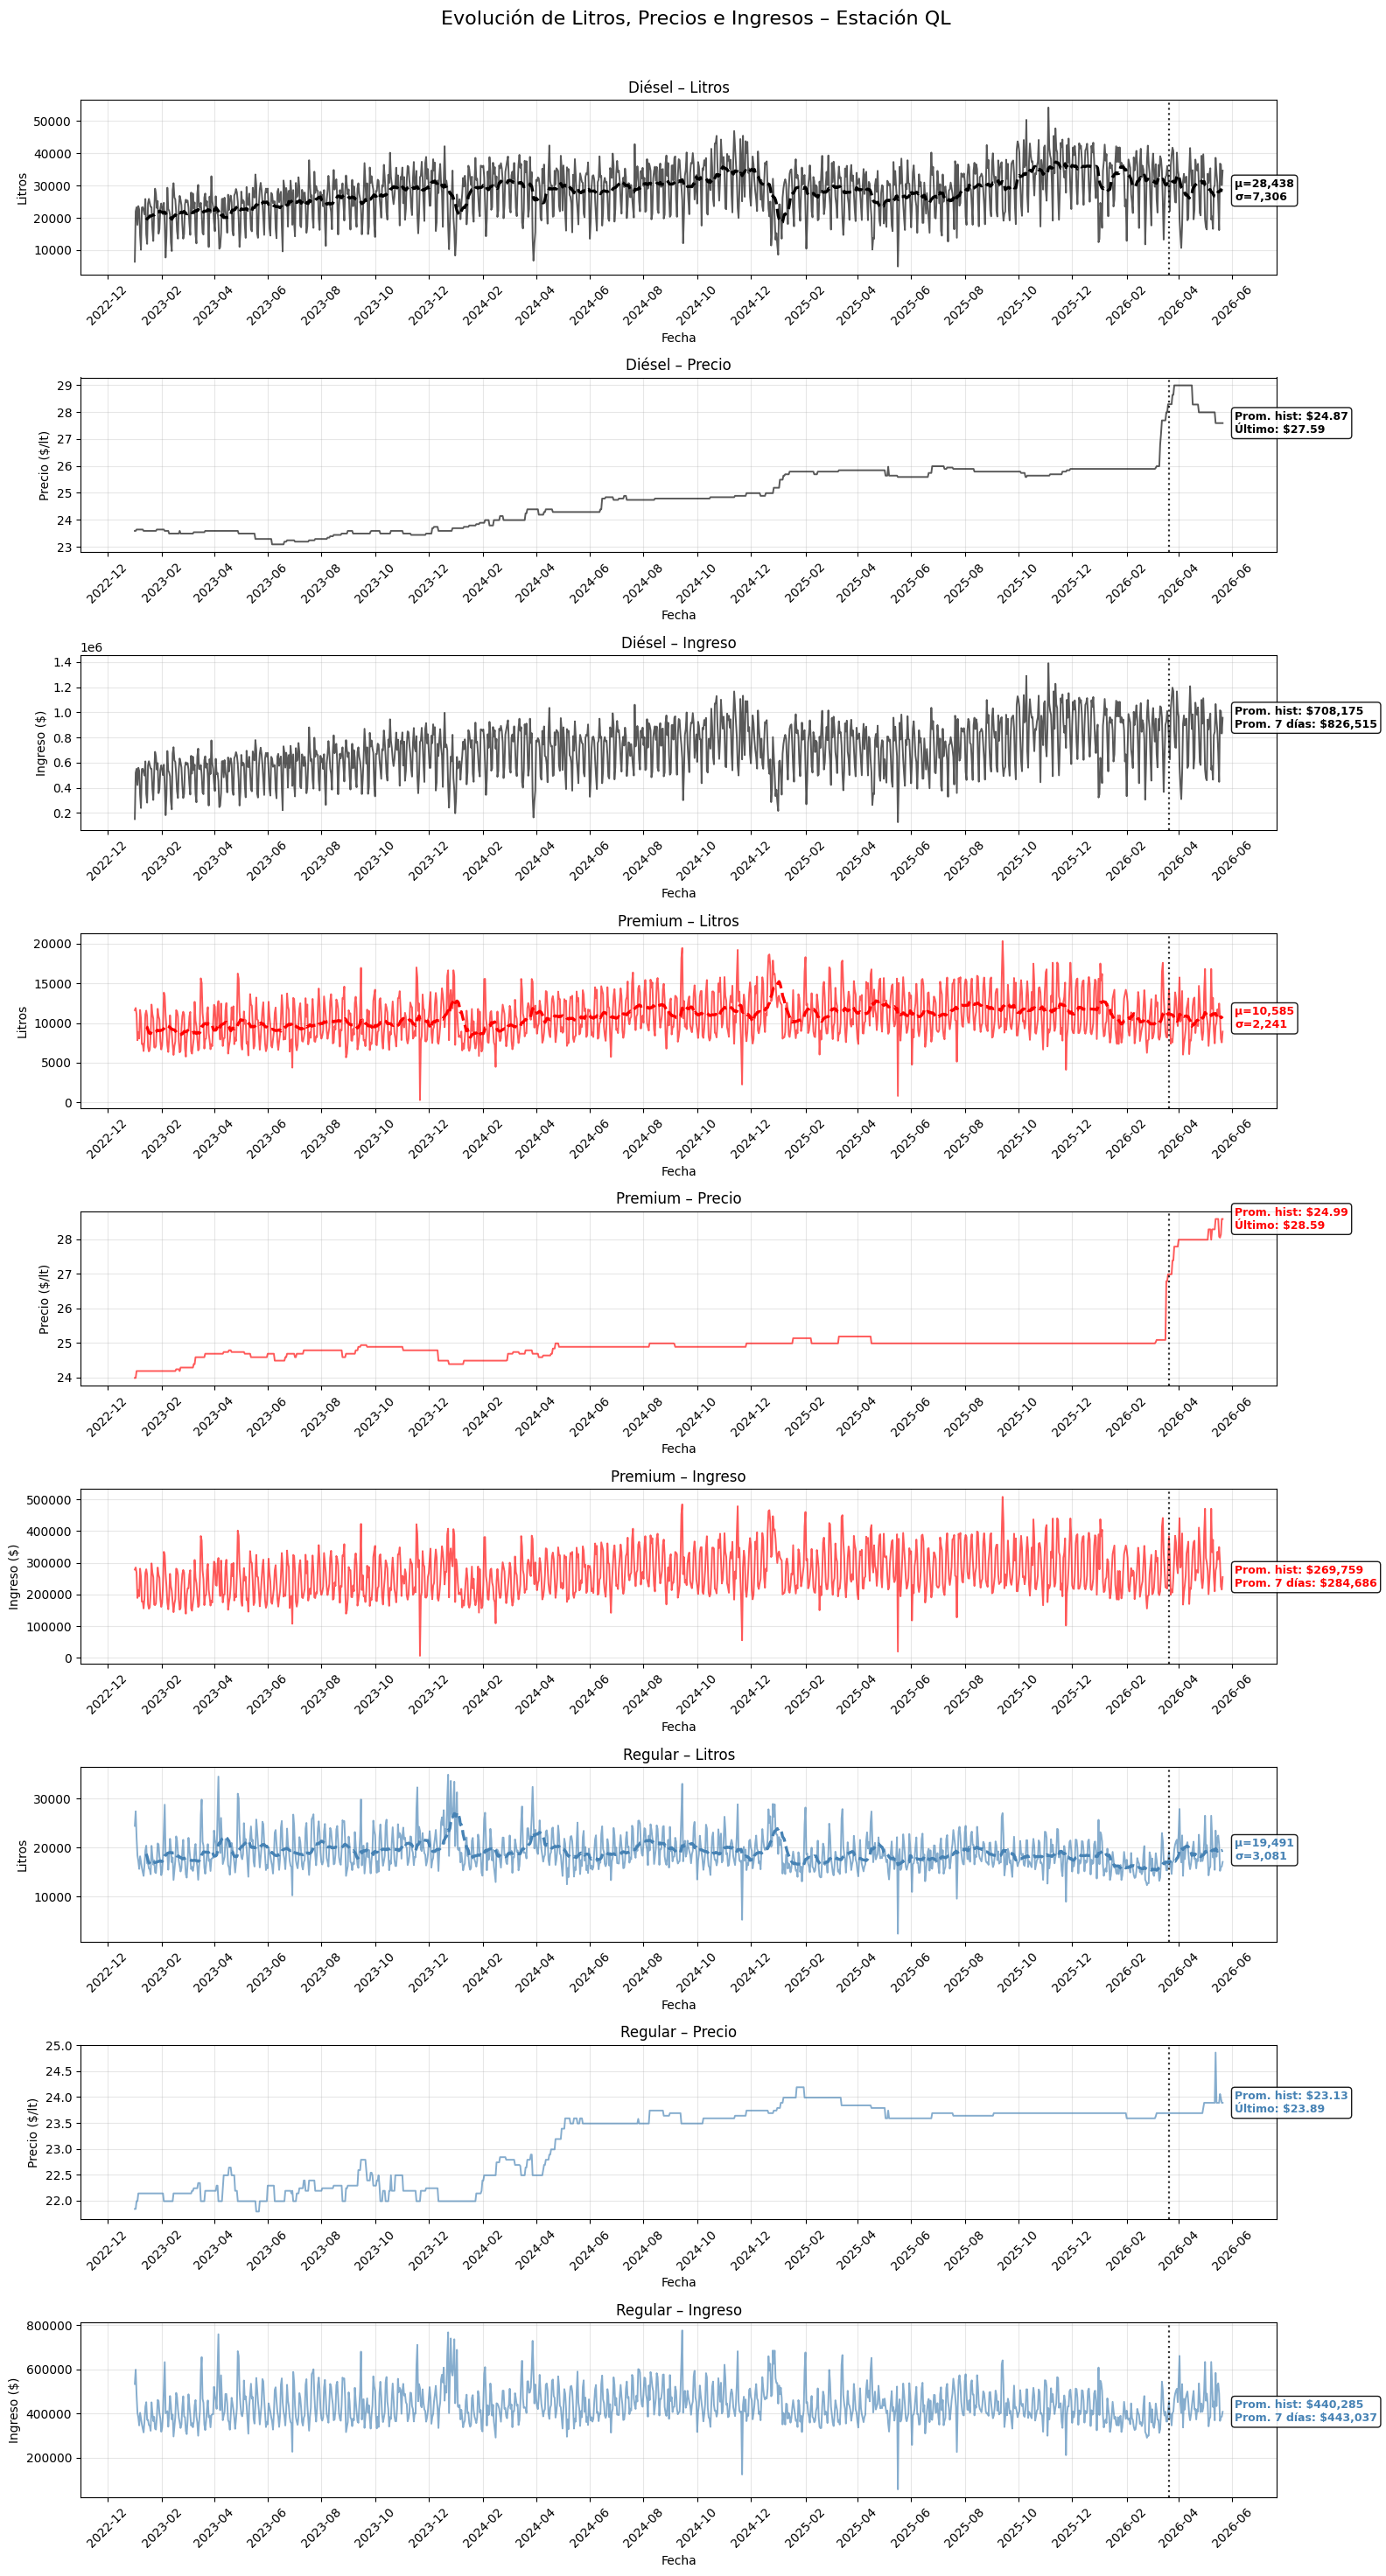

In [25]:
a='QL'
lts_precio(BD,a)

In [26]:
"""
def lts_totales_mensuales_indep(BD, estacion):
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import re

    # ==========================================================
    # FILTRAR ESTACIÓN Y ELIMINAR MES ACTUAL
    # ==========================================================
    df = BD[BD["Estación"] == estacion].copy()

    if df.empty:
        raise ValueError(f"No existe información para la estación {estacion}")

    df["Fecha"] = pd.to_datetime(df["Fecha"])

    # Mostrar únicamente meses completos (hasta el mes anterior)
    primer_dia_mes_actual = pd.Timestamp.today().to_period("M").to_timestamp()
    df = df[df["Fecha"] < primer_dia_mes_actual]

    if df.empty:
        raise ValueError(f"No hay meses completos disponibles para la estación {estacion}")

    # ==========================================================
    # CÁLCULOS
    # ==========================================================
    df_mensual = (
        df.groupby(pd.Grouper(key="Fecha", freq="MS"))
        .agg({
            "Diésel (Lts)": "sum",
            "Premium (Lts)": "sum",
            "Regular (Lts)": "sum"
        })
        .reset_index()
    )

    diesel = df_mensual["Diésel (Lts)"]
    premium = df_mensual["Premium (Lts)"]
    regular = df_mensual["Regular (Lts)"]
    totales = diesel + premium + regular

    # ==========================================================
    # ESTILO GENERAL
    # ==========================================================
    plt.style.use("seaborn-v0_8-whitegrid")
    
    # Conservamos el tamaño original del canvas
    fig, ax1 = plt.subplots(figsize=(18, 14))

    # ==========================================================
    # GRAFICA DE BARRAS (Ancho aumentado a 25)
    # ==========================================================
    ancho_barras = 25
    bars_diesel = ax1.bar(df_mensual["Fecha"], diesel, width=ancho_barras, color="#1A1A1A", label="Diésel", zorder=3)
    bars_premium = ax1.bar(df_mensual["Fecha"], premium, width=ancho_barras, bottom=diesel, color="#C1121F", label="Premium", zorder=3)
    bars_regular = ax1.bar(df_mensual["Fecha"], regular, width=ancho_barras, bottom=diesel + premium, color="#5bba6f", label="Regular", zorder=3)

    ax1.set_title(f"Volumen Mensual por Tipo de Combustible - {estacion}", fontsize=22, fontweight="bold", pad=30)
    ax1.set_ylabel("Litros Totales", fontsize=14, fontweight="bold")
    ax1.set_ylim(0, totales.max() * 1.35)

    # --- ETIQUETAS INTERNAS (Inclinadas y más grandes) ---
    def poner_etiquetas_segmento(barras, valores, color_texto):
        for barra, valor in zip(barras, valores):
            if valor < totales.max() * 0.035: continue
            miles = int(round(valor / 1000))
            ax1.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_y() + barra.get_height() / 2,
                f"{miles:,}",
                ha="center", 
                va="center", 
                fontsize=11,      # Más grandes
                fontweight="bold", 
                color=color_texto, 
                rotation=45,      # Inclinadas
                zorder=6
            )

    poner_etiquetas_segmento(bars_diesel, diesel, "white")
    poner_etiquetas_segmento(bars_premium, premium, "white")
    poner_etiquetas_segmento(bars_regular, regular, "black")

    # --- ETIQUETAS TOTALES (Superiores) ---
    for i, (x, total) in enumerate(zip(df_mensual["Fecha"], totales)):
        miles = int(round(total / 1000))
        offset = 15 if i % 2 == 0 else 35 
        ax1.annotate(
            f"{miles:,} mil",
            xy=(x, total), xytext=(0, offset),
            textcoords="offset points", ha="center", va="bottom",
            rotation=60, fontsize=12, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="#D9D9D9", alpha=0.9),
            zorder=7
        )

    # ==========================================================
    # FORMATO Y LÍNEAS DE AÑO
    # ==========================================================
    # Borrar líneas de cuadrícula
    ax1.grid(False)

    años = sorted(df_mensual["Fecha"].dt.year.unique())
    for año in años[1:]:
        fecha_año = pd.Timestamp(f"{año}-01-01")
        ax1.axvline(fecha_año, color="#070707", linestyle="--", linewidth=1.2, alpha=0.8, zorder=1)
        ax1.text(fecha_año, ax1.get_ylim()[1]*0.98, str(año), rotation=90, ha="right", va="top", 
                fontsize=10, fontweight="bold", backgroundcolor="white", zorder=2)

    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=10, fontweight="bold")

    ax1.legend(loc="upper left", frameon=True, fontsize=12).get_texts()[0].set_fontweight("bold")
    
    plt.tight_layout()

    # ==========================================================
    # EXPORTAR PDF
    # ==========================================================
    nombre_archivo = re.sub(r'[\\/*?:"<>|]', "", str(estacion)).strip()
    plt.savefig(f"{nombre_archivo}_barras.pdf", format="pdf", bbox_inches="tight")
    plt.show()

lts_totales_mensuales_indep(BD,"IXTAZACUALA")
"""

'\ndef lts_totales_mensuales_indep(BD, estacion):\n    import pandas as pd\n    import matplotlib.pyplot as plt\n    import matplotlib.dates as mdates\n    import re\n\n    # ==========================================================\n    # FILTRAR ESTACIÓN Y ELIMINAR MES ACTUAL\n    # ==========================================================\n    df = BD[BD["Estación"] == estacion].copy()\n\n    if df.empty:\n        raise ValueError(f"No existe información para la estación {estacion}")\n\n    df["Fecha"] = pd.to_datetime(df["Fecha"])\n\n    # Mostrar únicamente meses completos (hasta el mes anterior)\n    primer_dia_mes_actual = pd.Timestamp.today().to_period("M").to_timestamp()\n    df = df[df["Fecha"] < primer_dia_mes_actual]\n\n    if df.empty:\n        raise ValueError(f"No hay meses completos disponibles para la estación {estacion}")\n\n    # ==========================================================\n    # CÁLCULOS\n    # =======================================================

In [27]:
"""    GRAFICAS MENSUALES
def lts_totales_mensuales_indep(BD, estacion):
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import re

    # ==========================================================
    # FILTRAR ESTACIÓN Y ELIMINAR MES ACTUAL
    # ==========================================================
    df = BD[BD["Estación"] == estacion].copy()

    if df.empty:
        raise ValueError(f"No existe información para la estación {estacion}")

    df["Fecha"] = pd.to_datetime(df["Fecha"])

    # Mostrar únicamente meses completos (hasta el mes anterior)
    primer_dia_mes_actual = pd.Timestamp.today().to_period("M").to_timestamp()
    df = df[df["Fecha"] < primer_dia_mes_actual]

    if df.empty:
        raise ValueError(f"No hay meses completos disponibles para la estación {estacion}")

    # ==========================================================
    # CÁLCULOS
    # ==========================================================
    df["Total Ingreso"] = (
        (df["Diésel (Lts)"] * df["Precio D"]) +
        (df["Premium (Lts)"] * df["Precio P"]) +
        (df["Regular (Lts)"] * df["Precio R"])
    )

    df_mensual = (
        df.groupby(pd.Grouper(key="Fecha", freq="MS"))
        .agg({
            "Diésel (Lts)": "sum",
            "Premium (Lts)": "sum",
            "Regular (Lts)": "sum",
            "Total Ingreso": "sum"
        })
        .reset_index()
    )

    diesel = df_mensual["Diésel (Lts)"]
    premium = df_mensual["Premium (Lts)"]
    regular = df_mensual["Regular (Lts)"]
    ingresos = df_mensual["Total Ingreso"]
    totales = diesel + premium + regular

    # ==========================================================
    # ESTILO GENERAL
    # ==========================================================
    plt.style.use("seaborn-v0_8-whitegrid")
    COLOR_TITULO = "#00171f"
    COLOR_LINEA = "#d74e09"

    fig, (ax1, ax2) = plt.subplots(
        nrows=2, ncols=1, figsize=(18, 14), sharex=False
    )

    # ==========================================================
    # GRAFICA 1: BARRAS APILADAS
    # ==========================================================
    bars_diesel = ax1.bar(df_mensual["Fecha"], diesel, width=20, color="#1A1A1A", label="Diésel", zorder=3)
    bars_premium = ax1.bar(df_mensual["Fecha"], premium, width=20, bottom=diesel, color="#C1121F", label="Premium", zorder=3)
    bars_regular = ax1.bar(df_mensual["Fecha"], regular, width=20, bottom=diesel + premium, color="#5bba6f", label="Regular", zorder=3)

    ax1.set_title(f"Volumen Mensual por Tipo de Combustible - {estacion}", fontsize=18, fontweight="bold", pad=20)
    ax1.set_ylabel("Litros Totales", fontsize=12, fontweight="bold")
    ax1.set_ylim(0, totales.max() * 1.35)

    # --- ETIQUETAS INTERNAS (SE MANTIENEN) ---
    def poner_etiquetas_segmento(barras, valores, color_texto):
        for barra, valor in zip(barras, valores):
            if valor < totales.max() * 0.035: continue
            miles = int(round(valor / 1000))
            ax1.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_y() + barra.get_height() / 2,
                f"{miles:,}",
                ha="center", va="center", fontsize=8, fontweight="bold", color=color_texto, zorder=6
            )

    poner_etiquetas_segmento(bars_diesel, diesel, "white")
    poner_etiquetas_segmento(bars_premium, premium, "white")
    poner_etiquetas_segmento(bars_regular, regular, "black")

    # --- ETIQUETAS TOTALES (ROTADAS Y EN ZIG-ZAG) ---
    for i, (x, total) in enumerate(zip(df_mensual["Fecha"], totales)):
        miles = int(round(total / 1000))
        offset = 15 if i % 2 == 0 else 35 
        ax1.annotate(
            f"{miles:,} mil",
            xy=(x, total), xytext=(0, offset),
            textcoords="offset points", ha="center", va="bottom",
            rotation=60, fontsize=11, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="#D9D9D9", alpha=0.9),
            zorder=7
        )

    # ==========================================================
    # GRAFICA 2: LINEA DE INGRESOS
    # ==========================================================
    ax2.plot(df_mensual["Fecha"], ingresos, color=COLOR_LINEA, linewidth=3, marker="o", markersize=7, zorder=3)
    ax2.set_title(f"Ingreso Mensual Total ($) - {estacion}", fontsize=18, fontweight="bold", pad=20)
    ax2.set_ylabel("Ingresos Totales ($)", fontsize=12, fontweight="bold")
    ax2.set_ylim(ingresos.min() * 0.85, ingresos.max() * 1.30)

    # --- ETIQUETAS INGRESOS (ROTADAS Y SIN RUIDO) ---
    for i, (x, y) in enumerate(zip(df_mensual["Fecha"], ingresos)):
        dy = 22 if i % 2 == 0 else -32 
        ax2.annotate(
            f"${y/1_000_000:,.1f} M",
            xy=(x, y), xytext=(0, dy),
            textcoords="offset points", ha="center", va="center",
            rotation=45, fontsize=11, fontweight="bold", color=COLOR_LINEA,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor=COLOR_LINEA, linewidth=0.6, alpha=0.9),
            zorder=5
        )

    # ==========================================================
    # LÍNEAS DE AÑO (PUNTEADAS) Y FORMATO
    # ==========================================================
    for ax in [ax1, ax2]:
        años = sorted(df_mensual["Fecha"].dt.year.unique())
        for año in años[1:]:
            fecha_año = pd.Timestamp(f"{año}-01-01")
            ax.axvline(fecha_año, color="#070707", linestyle="--", linewidth=1.2, alpha=0.8, zorder=1) # Línea punteada
            ax.text(fecha_año, ax.get_ylim()[1]*0.98, str(año), rotation=90, ha="right", va="top", 
                    fontsize=10, fontweight="bold", backgroundcolor="white", zorder=2)

        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9, fontweight="bold")
        ax.grid(axis="y", linestyle="--", alpha=0.3)

    ax1.legend(loc="upper left", frameon=True, fontsize=10).get_texts()[0].set_fontweight("bold")
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.4)

    # ==========================================================
    # EXPORTAR PDF (SE MANTIENE)
    # ==========================================================
    nombre_archivo = re.sub(r'[\\/*?:"<>|]', "", str(estacion)).strip()
    plt.savefig(f"{nombre_archivo}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

a="QL"
lts_totales_mensuales_indep(BD,a)
"""

'    GRAFICAS MENSUALES\ndef lts_totales_mensuales_indep(BD, estacion):\n    import pandas as pd\n    import matplotlib.pyplot as plt\n    import matplotlib.dates as mdates\n    import re\n\n    # ==========================================================\n    # FILTRAR ESTACIÓN Y ELIMINAR MES ACTUAL\n    # ==========================================================\n    df = BD[BD["Estación"] == estacion].copy()\n\n    if df.empty:\n        raise ValueError(f"No existe información para la estación {estacion}")\n\n    df["Fecha"] = pd.to_datetime(df["Fecha"])\n\n    # Mostrar únicamente meses completos (hasta el mes anterior)\n    primer_dia_mes_actual = pd.Timestamp.today().to_period("M").to_timestamp()\n    df = df[df["Fecha"] < primer_dia_mes_actual]\n\n    if df.empty:\n        raise ValueError(f"No hay meses completos disponibles para la estación {estacion}")\n\n    # ==========================================================\n    # CÁLCULOS\n    # =================================

In [28]:
#resultados,modelo=modelo_fourier_operativo(BD,a)
#tabla_operativa(resultados)

In [29]:
#estadisticas(BD,a)
#variacion(BD,a)

In [30]:
tabla=tabla_litros_feb_14_28(BD,a)
#tabla

In [35]:
promedio_sem(BD,a)

EWMA 4 (Detectar)  EWMA 8 (Confirmar)  \
Combustible Día                                                
Diésel      Lunes                35423.6             35420.3   
            Miércoles            35333.8             35243.2   
            Jueves               34557.0             32886.6   
            Martes               33147.3             35005.7   
            Viernes              26921.0             27151.7   
            Sábado               20596.3             20615.3   
            Domingo              18476.9             19669.5   
Premium     Viernes              14433.1             12986.9   
            Domingo              12033.1             12415.5   
            Sábado               11944.6             12293.5   
            Jueves               10602.7             10764.0   
            Lunes                 9421.5              8573.0   
            Miércoles             8933.9              8957.6   
            Martes                8058.6              8122.0   
Regular     Viernes              23544.9             21582.5   
            Sábado               21019.0             20347.7   
            Domingo              18801.1             19222.6   
            Miércoles            18217.0             18388.1   
            Jueves               17974.9             19235.4   
            Lunes                17925.1             17668.2   
            Martes               15775.5             16437.8   

                       EWMA 12 (Validar)  
Combustible Día                           
Diésel      Lunes                33957.4  
            Miércoles            35619.6  
            Jueves               33763.5  
            Martes               35687.5  
            Viernes              30029.5  
            Sábado               22718.3  
            Domingo              18435.3  
Premium     Viernes              12918.8  
            Domingo              12553.4  
            Sábado               12868.0  
            Jueves               10288.4  
            Lunes                 8585.8  
            Miércoles             8789.2  
            Martes                8052.4  
Regular     Viernes              20835.1  
            Sábado               19839.6  
            Domingo              17985.9  
            Miércoles            16882.3  
            Jueves               17789.7  
            Lunes                16935.5  
            Martes               15769.6

In [32]:
#promedio_mensual(BD,a)

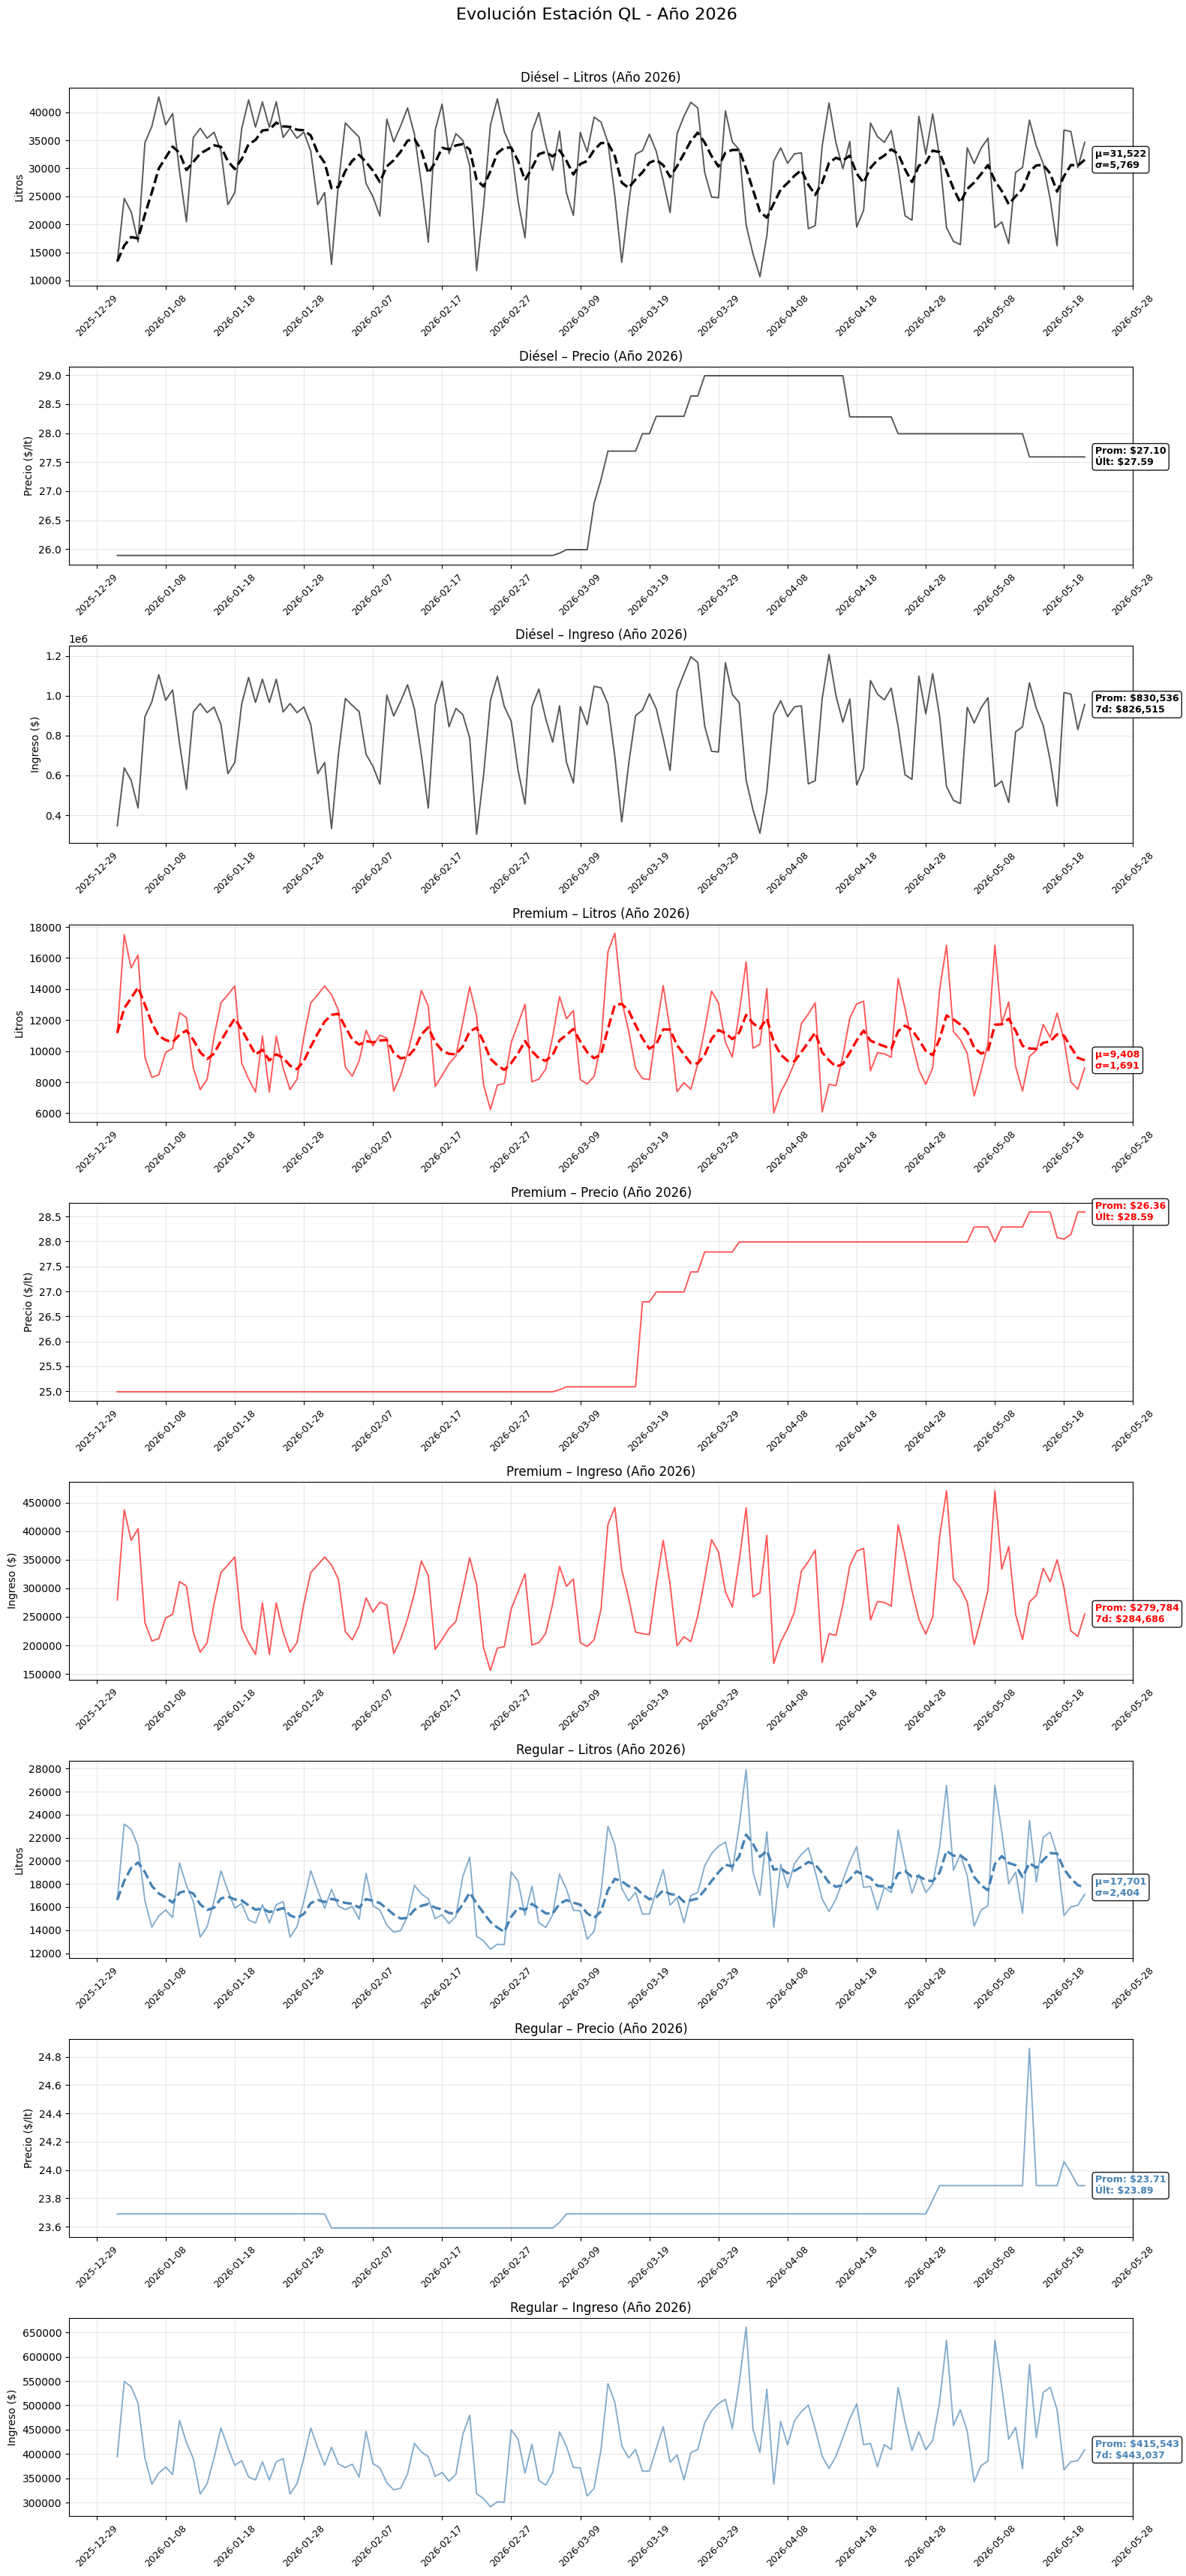

In [33]:
def lts_precio1(BD, estacion, periodo="TODOS"):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    # =========================
    # FILTRO Y PREPARACIÓN
    # =========================
    BD["Fecha"] = pd.to_datetime(BD["Fecha"])
    
    df = (
        BD[BD["Estación"] == estacion]
        .sort_values("Fecha")
        .copy()
    )

    if df.empty:
        raise ValueError(f"No hay datos para la estación {estacion}")

    if str(periodo).upper() == "TODOS":
        titulo_periodo = "Histórico Completo"
    elif str(periodo).isdigit() and len(str(periodo)) == 4:
        df = df[df["Fecha"].dt.year == int(periodo)]
        titulo_periodo = f"Año {periodo}"
    else:
        try:
            fecha_inicio = pd.to_datetime(periodo)
            df = df[df["Fecha"] >= fecha_inicio]
            titulo_periodo = f"Desde {fecha_inicio.strftime('%d-%m-%Y')}"
        except:
            titulo_periodo = "Histórico Completo"

    if df.empty:
        print(f"La consulta para {estacion} en el periodo {periodo} no arrojó datos.")
        return

    df["Ingreso D"] = df["Diésel (Lts)"] * df["Precio D"]
    df["Ingreso P"] = df["Premium (Lts)"] * df["Precio P"]
    df["Ingreso R"] = df["Regular (Lts)"] * df["Precio R"]

    series = [
        ("Diésel (Lts)",  "Diésel – Litros",   "Litros",        "black",     "litros"),
        ("Precio D",      "Diésel – Precio",   "Precio ($/lt)", "black",     "precio"),
        ("Ingreso D",     "Diésel – Ingreso",  "Ingreso ($)",   "black",     "ingreso"),
        ("Premium (Lts)", "Premium – Litros",  "Litros",        "red",       "litros"),
        ("Precio P",      "Premium – Precio",  "Precio ($/lt)", "red",       "precio"),
        ("Ingreso P",     "Premium – Ingreso", "Ingreso ($)",   "red",       "ingreso"),
        ("Regular (Lts)", "Regular – Litros",  "Litros",        "steelblue", "litros"),
        ("Precio R",      "Regular – Precio",  "Precio ($/lt)", "steelblue", "precio"),
        ("Ingreso R",     "Regular – Ingreso", "Ingreso ($)",   "steelblue", "ingreso"),
    ]

    fig, axes = plt.subplots(nrows=9, ncols=1, figsize=(16, 35), sharex=False)

    # ========================================================
    # AJUSTE DE FRECUENCIA DE FECHAS (MODIFICADO)
    # ========================================================
    dias_rango = (df["Fecha"].max() - df["Fecha"].min()).days
    
    if dias_rango <= 31:
        # Menos de un mes: mostrar cada 2 días
        locator = mdates.DayLocator(interval=2)
    elif dias_rango <= 90:
        # Hasta 3 meses: mostrar cada 5 días
        locator = mdates.DayLocator(interval=5)
    elif dias_rango <= 180:
        # Hasta 6 meses: mostrar cada 10 días
        locator = mdates.DayLocator(interval=10)
    elif dias_rango <= 365:
        # Hasta un año: mostrar cada 15 días
        locator = mdates.DayLocator(interval=15)
    else:
        # Más de un año: mostrar cada mes
        locator = mdates.MonthLocator(interval=1)
        
    formatter = mdates.DateFormatter("%Y-%m-%d")

    for ax, (col, titulo, ylabel, color, tipo) in zip(axes, series):
        ax.plot(df["Fecha"], df[col], color=color, linewidth=1.4, alpha=0.65)

        if tipo == "litros":
            ewma_mean = df[col].ewm(span=7, adjust=False).mean()
            ax.plot(df["Fecha"], ewma_mean, color=color, linewidth=2.4, linestyle="--")
            ewma_std = np.sqrt((df[col] - ewma_mean).pow(2).ewm(span=14, adjust=False).mean())
            x_last, mean_last, std_last = df["Fecha"].iloc[-1], ewma_mean.iloc[-1], ewma_std.iloc[-1]
            ax.annotate(f"μ={mean_last:,.0f}\nσ={std_last:,.0f}", xy=(x_last, mean_last), 
                        xytext=(10, 0), textcoords="offset points", va="center", fontsize=9, 
                        fontweight="bold", color=color, bbox=dict(boxstyle="round", fc="white", alpha=0.9))

        elif tipo == "precio":
            precio_prom, precio_last, x_last = df[col].mean(), df[col].iloc[-1], df["Fecha"].iloc[-1]
            ax.annotate(f"Prom: ${precio_prom:,.2f}\nÚlt: ${precio_last:,.2f}", xy=(x_last, precio_last), 
                        xytext=(10, 0), textcoords="offset points", va="center", fontsize=9, 
                        fontweight="bold", color=color, bbox=dict(boxstyle="round", fc="white", alpha=0.9))

        elif tipo == "ingreso":
            ingreso_hist, ingreso_7d = df[col].mean(), df[col].tail(7).mean()
            x_last, y_last = df["Fecha"].iloc[-1], df[col].iloc[-1]
            ax.annotate(f"Prom: ${ingreso_hist:,.0f}\n7d: ${ingreso_7d:,.0f}", xy=(x_last, y_last), 
                        xytext=(10, 0), textcoords="offset points", va="center", fontsize=9, 
                        fontweight="bold", color=color, bbox=dict(boxstyle="round", fc="white", alpha=0.9))

        ax.set_title(f"{titulo} ({titulo_periodo})", fontsize=12)
        ax.set_ylabel(ylabel)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
        ax.tick_params(axis="x", rotation=45, labelsize=9)
        ax.grid(alpha=0.3)

    fig.suptitle(f"Evolución Estación {estacion} - {titulo_periodo}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

lts_precio1(BD,a, periodo="2026")

# ANALISIS EXTRAS (OJO, SON DE PRUEBA)


## FUNCIONES



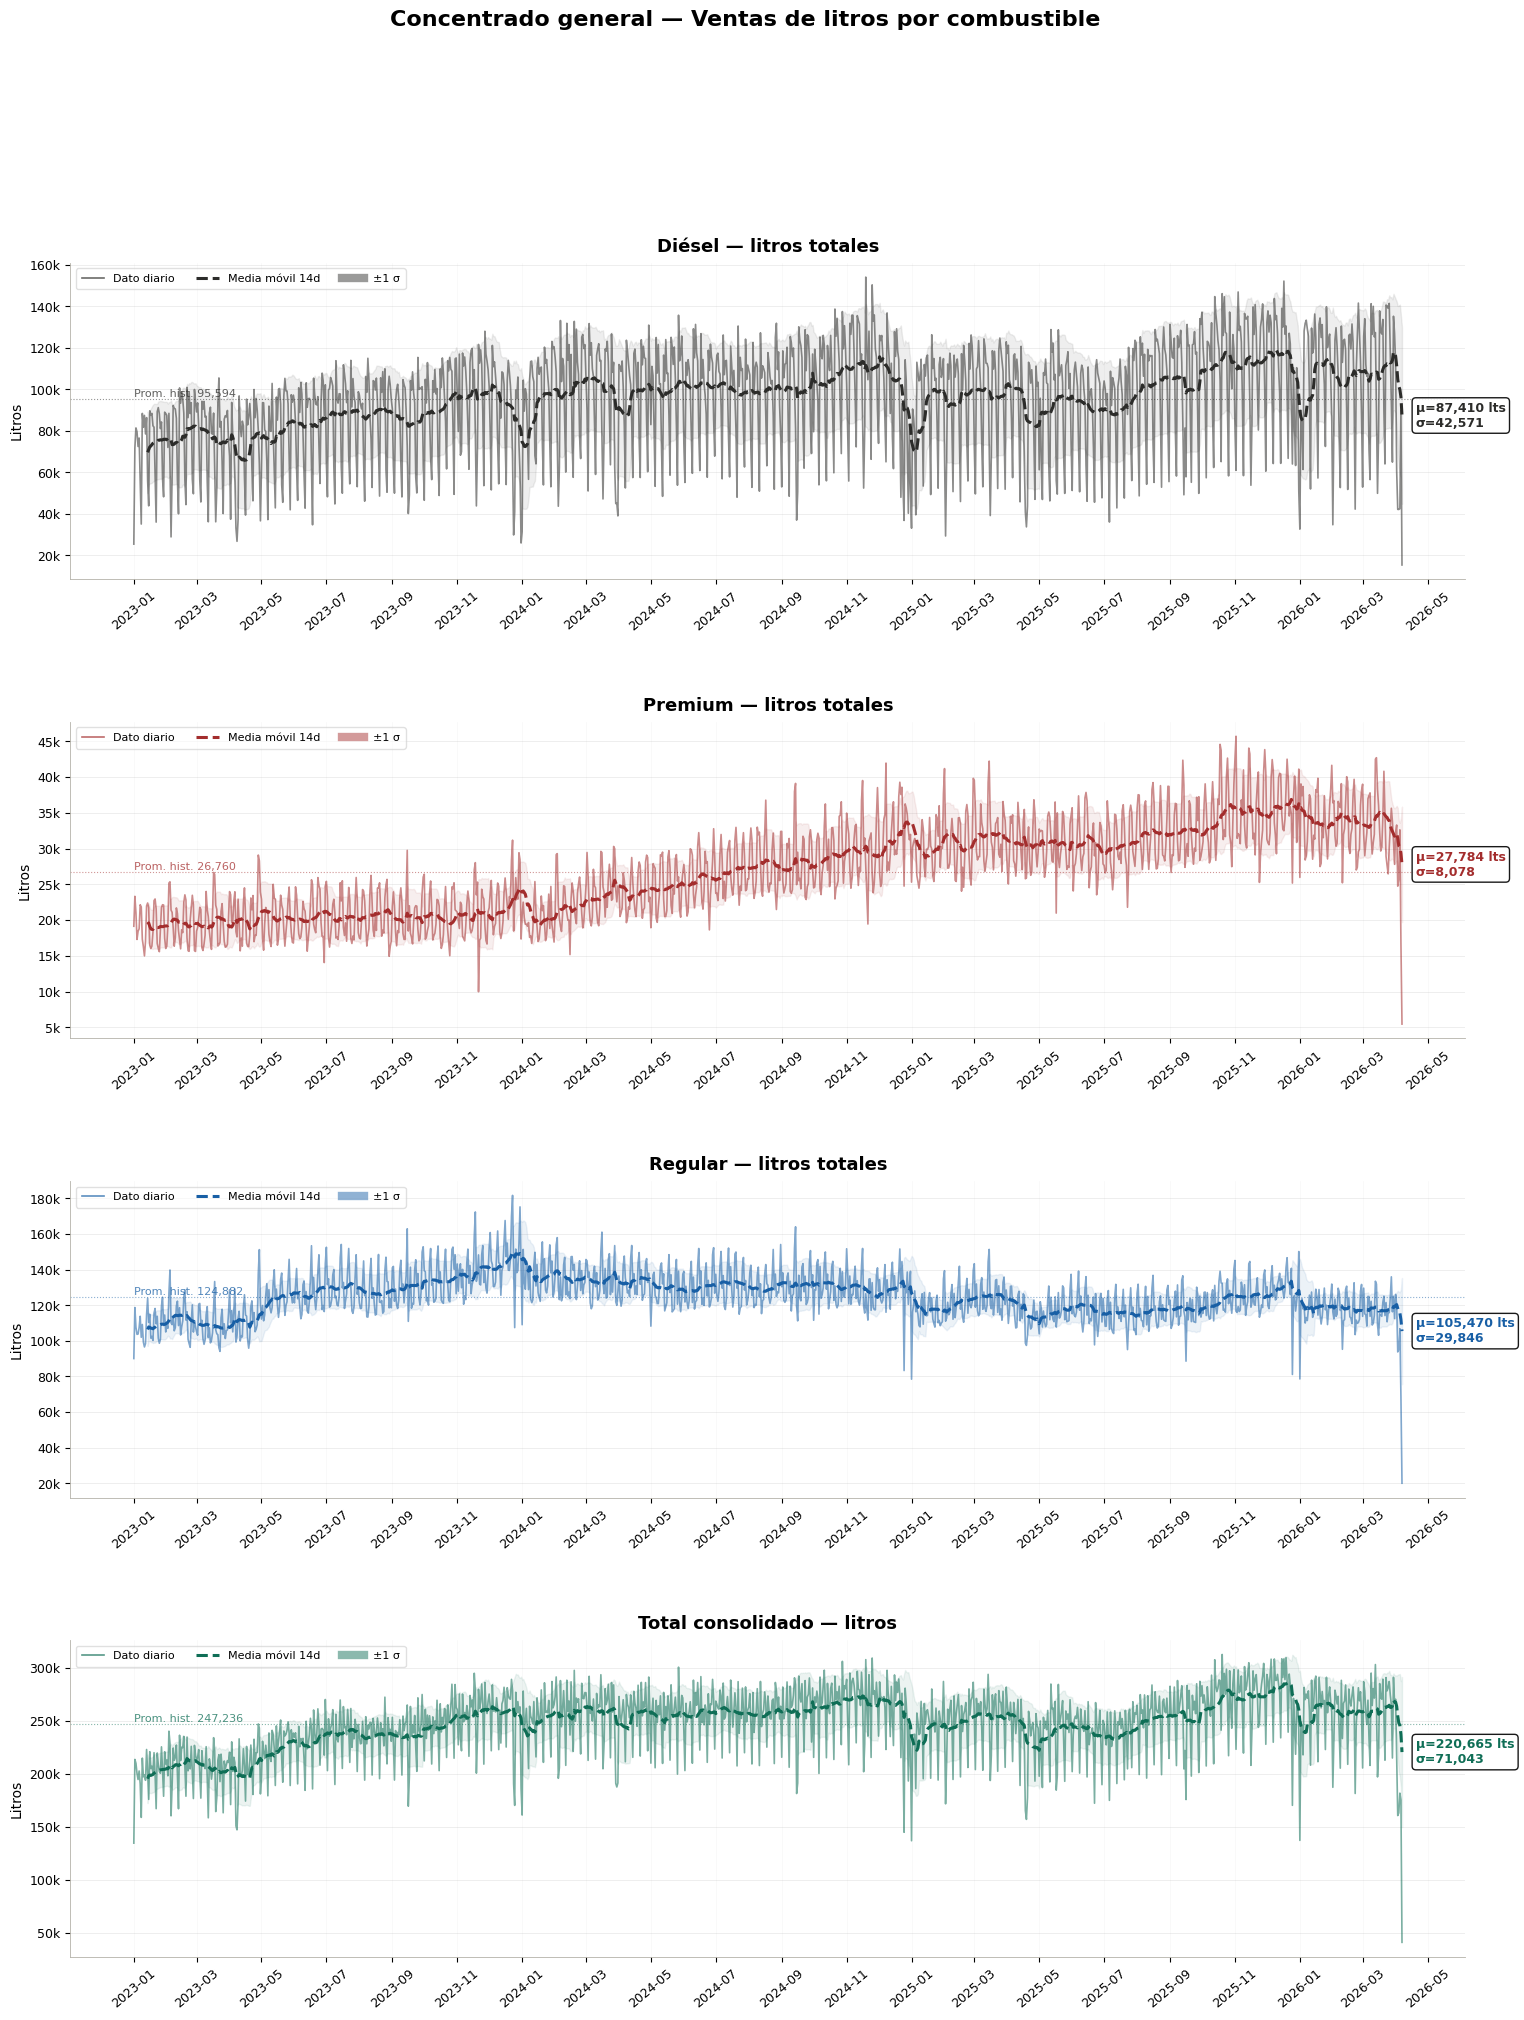

In [82]:
def concentrado_litros(BD):

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import matplotlib.ticker as mticker
    from matplotlib.lines import Line2D

    DIESEL_COLOR   = "#2C2C2A"
    PREMIUM_COLOR  = "#A32D2D"
    REGULAR_COLOR  = "#185FA5"
    TOTAL_COLOR    = "#0F6E56"

    ALPHA_LINE  = 0.55
    ALPHA_FILL  = 0.08
    LW_RAW      = 1.2
    LW_SMOOTH   = 2.2
    WINDOW      = 14

    # ========================
    # AGRUPADO POR FECHA
    # ========================
    df = (
        BD.groupby("Fecha", as_index=False)
        .agg(
            Diesel=("Diésel (Lts)",   "sum"),
            Premium=("Premium (Lts)", "sum"),
            Regular=("Regular (Lts)", "sum"),
        )
        .sort_values("Fecha")
        .copy()
    )

    df["Total"] = df["Diesel"] + df["Premium"] + df["Regular"]

    locator   = mdates.MonthLocator(interval=2)
    formatter = mdates.DateFormatter("%Y-%m")

    def fmt_lts(x, pos):
        if x >= 1_000_000:
            return f"{x/1_000_000:.1f}M"
        if x >= 1_000:
            return f"{x/1_000:.0f}k"
        return f"{x:.0f}"

    def annotate_stat(ax, series, color, fecha):
        ma   = series.rolling(WINDOW).mean()
        last = ma.iloc[-1]
        std  = series.rolling(WINDOW).std().iloc[-1]
        ax.annotate(
            f"μ={last:,.0f} lts\nσ={std:,.0f}",
            xy=(fecha, last),
            xytext=(10, 0),
            textcoords="offset points",
            va="center",
            fontsize=9,
            fontweight="bold",
            color=color,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9),
        )
        return ma

    # ========================
    # FIGURA
    # ========================
    fig, axes = plt.subplots(
        nrows=4,
        ncols=1,
        figsize=(18, 22),
        sharex=False,
    )

    series_cfg = [
        ("Diesel",  "Diésel — litros totales",   DIESEL_COLOR),
        ("Premium", "Premium — litros totales",  PREMIUM_COLOR),
        ("Regular", "Regular — litros totales",  REGULAR_COLOR),
        ("Total",   "Total consolidado — litros", TOTAL_COLOR),
    ]

    for ax, (col, titulo, color) in zip(axes, series_cfg):

        raw   = df[col]
        fecha = df["Fecha"]
        x_last = fecha.iloc[-1]

        # línea cruda
        ax.plot(fecha, raw, color=color, linewidth=LW_RAW,
                alpha=ALPHA_LINE, zorder=2)

        # media móvil
        ma = raw.rolling(WINDOW).mean()
        ax.plot(fecha, ma, color=color, linewidth=LW_SMOOTH,
                linestyle="--", zorder=3, label=f"Media móvil {WINDOW}d")

        # banda ±1σ
        std_roll = raw.rolling(WINDOW).std()
        ax.fill_between(
            fecha,
            ma - std_roll,
            ma + std_roll,
            color=color,
            alpha=ALPHA_FILL,
            zorder=1,
            label="±1 σ",
        )

        # anotación
        annotate_stat(ax, raw, color, x_last)

        # promedio histórico
        hist_mean = raw.mean()
        ax.axhline(
            hist_mean,
            color=color,
            linewidth=0.8,
            linestyle=":",
            alpha=0.5,
            zorder=1,
        )
        ax.text(
            fecha.iloc[0],
            hist_mean * 1.01,
            f"Prom. hist. {hist_mean:,.0f}",
            fontsize=8,
            color=color,
            alpha=0.75,
        )

        # eje y
        ax.set_title(titulo, fontsize=13, fontweight="bold", pad=8)
        ax.set_ylabel("Litros", fontsize=10)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_lts))

        # eje x
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
        ax.tick_params(axis="x", rotation=40, labelsize=9)
        ax.tick_params(axis="y", labelsize=9)

        # grid
        ax.grid(axis="y", alpha=0.25, linewidth=0.6)
        ax.grid(axis="x", alpha=0.12, linewidth=0.4)
        ax.set_axisbelow(True)

        # spines limpios
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        for spine in ["left", "bottom"]:
            ax.spines[spine].set_linewidth(0.6)
            ax.spines[spine].set_color("#B4B2A9")

        # leyenda compacta
        legend_elements = [
            Line2D([0], [0], color=color, lw=LW_RAW,  alpha=0.7, label="Dato diario"),
            Line2D([0], [0], color=color, lw=LW_SMOOTH, linestyle="--", label=f"Media móvil {WINDOW}d"),
            Line2D([0], [0], color=color, lw=6, alpha=ALPHA_FILL * 6, label="±1 σ"),
        ]
        ax.legend(
            handles=legend_elements,
            fontsize=8,
            framealpha=0.6,
            loc="upper left",
            ncol=3,
            borderpad=0.5,
        )

    # ========================
    # PANEL INFERIOR — stacked
    # ========================
    fig.subplots_adjust(hspace=0.45)

    fig.suptitle(
        "Concentrado general — Ventas de litros por combustible",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )

    plt.savefig(
        "concentrado_litros.png",
        dpi=150,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()
concentrado_litros(BD)